# 04 · 事件传导预测模型

本 notebook 展示 Phase 4 模型的完整训练与分析流程：

1. 历史事件数据库查看
2. 特征分布探索 
3. 模型训练与 CV 评分
4. 特征重要性分析
5. SHAP 可解释性
6. 样本外预测 + 决策报告
7. 回测结果可视化

In [1]:
import sys, warnings
from pathlib import Path

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["font.sans-serif"] = ["Noto Sans CJK SC", "WenQuanYi Zen Hei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
import matplotlib.ticker as mticker

warnings.filterwarnings('ignore')

repo_root = Path.cwd().parent
DATA_ROOT = repo_root / 'data'
print(f'Data root: {DATA_ROOT}')

Data root: /data00/home/guohuanwei.cztj/git_files/trade/data


## 1 · 历史事件数据库

Total events: 3


,event_date,event_type,magnitude,actor_type,primary_sector,breadth,sentiment_score,news_volume,summary,source_url,actor_risk_score,event_id
0,2026-03-04,other,1.0,unknown,SW_航运,sector,-0.183333,17,莫德纳(MRNA)股价大涨，创2024年新高。,,0.4,617abc13eecd
1,2026-03-05,other,1.0,unknown,SW_石化,sector,-0.118182,22,种业板块今日大跌，多股跌幅超10%,,0.4,aaa0bd5ca571
2,2026-03-06,other,0.9,unknown,SW_半导体,sector,-0.251515,32,伊朗军舰因故障转移至斯里兰卡港口,,0.4,eddd32e488c6


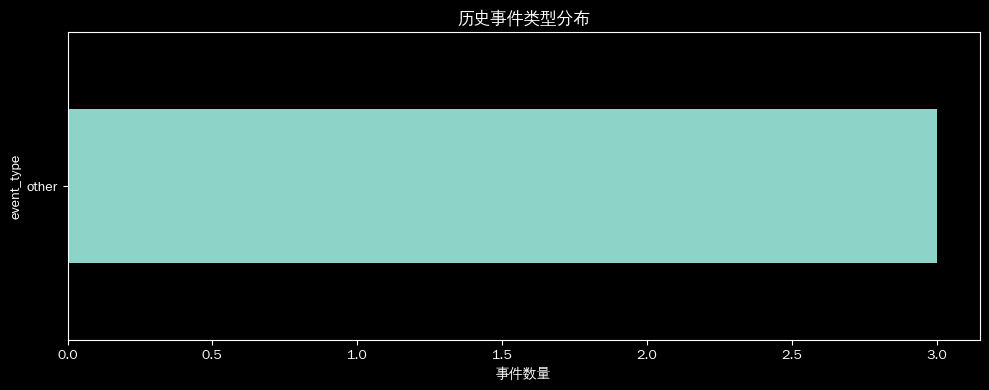

In [2]:
from trade_py.db.event_db import EventDatabase, EventType

db = EventDatabase(DATA_ROOT)
events = db.events
print(f'Total events: {len(events)}')

if events:
    df_events = db.to_dataframe()
    display(df_events.head(10))
    fig, ax = plt.subplots(figsize=(10, 4))
    df_events['event_type'].value_counts().plot(kind='barh', ax=ax)
    ax.set_title('历史事件类型分布')
    ax.set_xlabel('事件数量')
    plt.tight_layout()
    plt.show()
else:
    print('No events yet. Run: trade model build-features')

## 2 · 特征数据探索

In [3]:
from trade_py.analysis.feature_builder import ALL_FEATURE_COLS, GROUP_A_COLS, GROUP_B_COLS, GROUP_C_COLS, GROUP_D_COLS

features_path = DATA_ROOT / 'events' / 'features.parquet'
labels_path   = DATA_ROOT / 'events' / 'propagation_labels.parquet'

if features_path.exists() and labels_path.exists():
    df_feat = pd.read_parquet(features_path)
    df_lbl  = pd.read_parquet(labels_path)
    df = df_feat.merge(df_lbl, on=['event_id', 'symbol'], how='inner', suffixes=('', '_lbl'))
    if 'date_lbl' in df.columns:
        df = df.drop(columns=['date_lbl'])
    print(f'Feature rows: {len(df_feat):,}  |  Label rows: {len(df_lbl):,}  |  Merged: {len(df):,}')
    print(f'Feature columns: {len(ALL_FEATURE_COLS)}')
    display(df[GROUP_C_COLS].describe().round(4))
else:
    print('Features/labels not built yet.')
    df = pd.DataFrame()


Feature rows: 435  |  Label rows: 14  |  Merged: 14
Feature columns: 57


,kdj_zone,kdj_cross,kdj_divergence,macd_cross,macd_histogram_slope,macd_zero_position,rsi_14,rsi_zone,rsi_divergence,bb_position,...,momentum_60d,ma_trend,volatility_20d,liquidity_20d,gap_up_size,gap_up_volume_ratio,dist_to_52w_high,dist_to_52w_low,volume_poc_dist,auction_vol_ratio
count,14.0000,14.0,14.0,14.0000,14.0000,14.0000,14.0000,14.0000,14.0,14.0000,...,14.0000,14.0000,14.0000,14.0000,14.0000,14.0000,14.0000,14.0000,14.0000,14.0
mean,0.5714,0.0,0.0,-0.0714,-0.4222,-0.7143,38.6210,0.8571,0.0,-0.5892,...,-0.1093,-0.7143,0.3370,2.1115,-0.0082,0.8756,0.5134,0.1955,-0.0880,0.0
std,0.5136,0.0,0.0,0.2673,0.4446,0.7263,12.6395,0.3631,0.0,0.5231,...,0.2462,0.7263,0.1798,1.1940,0.0252,0.9889,0.5790,0.2250,0.1810,0.0
min,0.0000,0.0,0.0,-1.0000,-1.1464,-1.0000,18.9230,0.0000,0.0,-1.1222,...,-0.6042,-1.0000,0.0886,0.4260,-0.0640,0.0261,0.0383,0.0000,-0.5247,0.0
25%,0.0000,0.0,0.0,0.0000,-0.8251,-1.0000,32.5884,1.0000,0.0,-0.8639,...,-0.1381,-1.0000,0.1878,1.3499,-0.0090,0.4402,0.1863,0.0192,-0.0652,0.0
50%,1.0000,0.0,0.0,0.0000,-0.2389,-1.0000,38.8020,1.0000,0.0,-0.7372,...,-0.0834,-1.0000,0.3412,2.0392,-0.0015,0.7953,0.2553,0.1213,-0.0412,0.0
75%,1.0000,0.0,0.0,0.0000,-0.1191,-1.0000,41.2691,1.0000,0.0,-0.5992,...,-0.0526,-1.0000,0.4519,2.4399,0.0051,0.8949,0.6027,0.3031,-0.0138,0.0
max,1.0000,0.0,0.0,0.0000,0.0538,1.0000,63.2045,1.0000,0.0,0.5990,...,0.3486,1.0000,0.6344,4.6745,0.0165,4.1192,1.8929,0.6540,0.0797,0.0


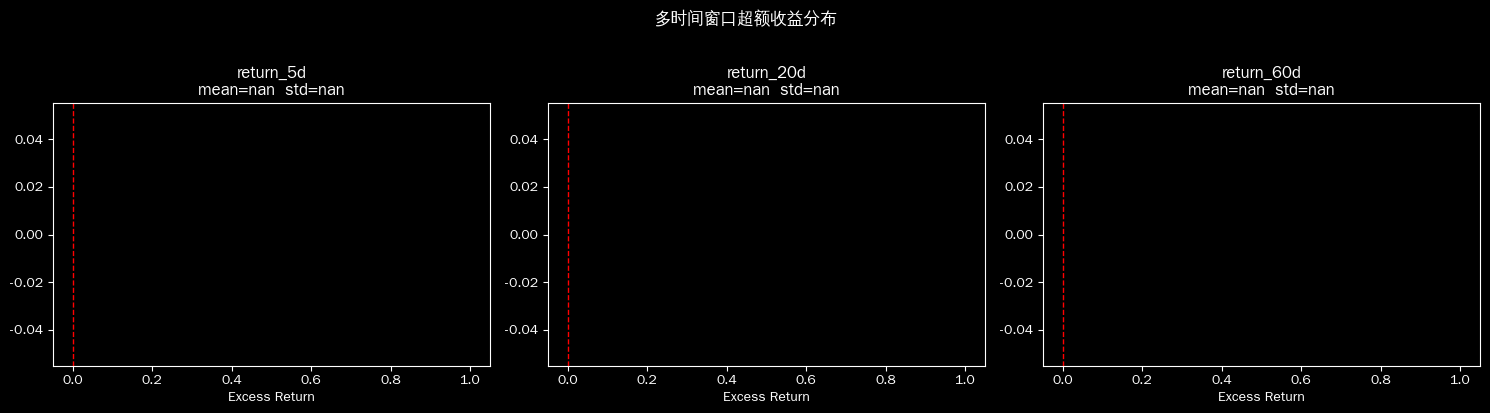

In [4]:
# Label distribution (if data available)
if not df.empty and 'return_20d' in df.columns:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, col in zip(axes, ['return_5d', 'return_20d', 'return_60d']):
        if col in df.columns:
            data = df[col].dropna()
            ax.hist(data, bins=50, edgecolor='none', alpha=0.7)
            ax.axvline(0, color='red', linestyle='--', linewidth=1)
            ax.set_title(f'{col}\nmean={data.mean():.3f}  std={data.std():.3f}')
            ax.set_xlabel('Excess Return')
    plt.suptitle('多时间窗口超额收益分布', y=1.02)
    plt.tight_layout()
    plt.show()

## 3 · 模型训练

In [5]:
from trade_py.analysis.model_trainer import PropagationModel

model = PropagationModel(DATA_ROOT)

if features_path.exists() and labels_path.exists():
    model.load_data()
    cv_scores = model.train(n_cv_splits=5)
    print('\n=== CV Scores ===')
    for target, score in cv_scores.items():
        metric = 'IC' if 'return' in target else 'AUC'
        print(f'  {target:<25s} {metric}={score:.4f}')
    model.save(DATA_ROOT / 'models' / 'propagation')
else:
    print('Skipping training – data not built yet')
    print('Run:  trade model train')

Not enough data for cross-validation – training on full set
Target loss_5pct_20d has too few positive samples (2) – skipping
Target drawdown_20pct has too few positive samples (0) – skipping



=== CV Scores ===
  return_5d                 IC=nan
  return_20d                IC=nan
  return_60d                IC=nan


## 4 · 特征重要性

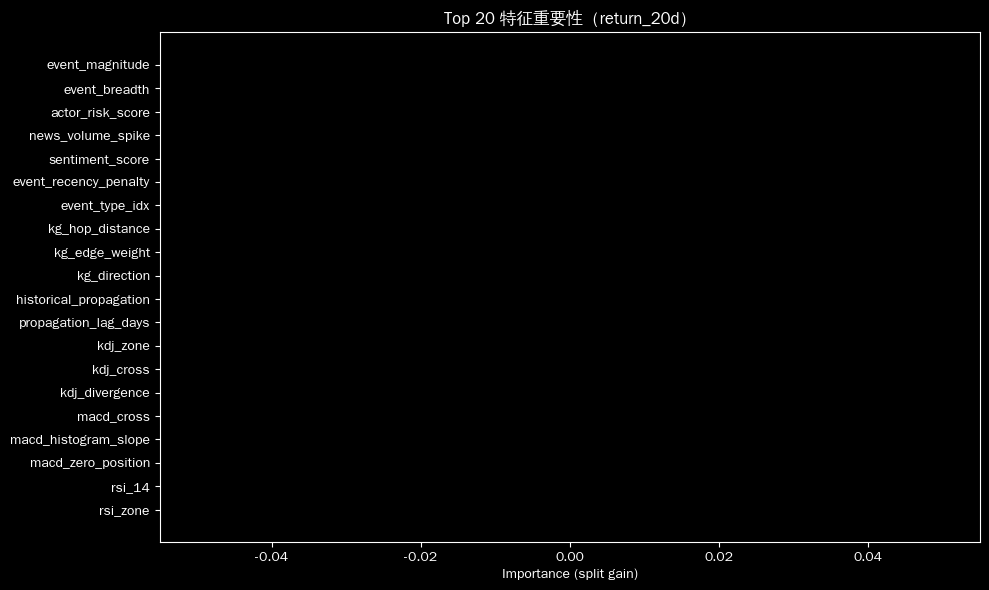

,feature,importance
0,event_magnitude,0
1,event_breadth,0
2,actor_risk_score,0
3,news_volume_spike,0
4,sentiment_score,0
5,event_recency_penalty,0
6,event_type_idx,0
7,kg_hop_distance,0
8,kg_edge_weight,0
9,kg_direction,0


In [6]:
if (DATA_ROOT / 'models' / 'propagation' / 'return_20d.pkl').exists():
    if not model._models:  # load if not already trained in this session
        model.load(DATA_ROOT / 'models' / 'propagation')
    
    imp = model.feature_importance('return_20d', top_n=20)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(imp['feature'][::-1], imp['importance'][::-1])
    ax.set_title('Top 20 特征重要性（return_20d）')
    ax.set_xlabel('Importance (split gain)')
    plt.tight_layout()
    plt.show()
    display(imp)
else:
    print('Models not trained yet')

## 5 · SHAP 可解释性

In [7]:
try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False
    print('shap not installed. Run: pip install shap')

if HAS_SHAP and not df.empty and model._models:
    feat_cols = model._feature_cols
    X_sample = df[feat_cols].fillna(0).head(200).to_numpy(dtype='float32')
    
    lgb_model = model._models.get('return_20d')
    if lgb_model is not None:
        explainer = shap.TreeExplainer(lgb_model)
        shap_vals = explainer.shap_values(X_sample)
        
        plt.figure(figsize=(10, 7))
        shap.summary_plot(shap_vals, X_sample, feature_names=feat_cols,
                          show=False, max_display=15)
        plt.title('SHAP Summary Plot: return_20d')
        plt.tight_layout()
        plt.show()

shap not installed. Run: pip install shap


## 6 · 决策报告示例

In [8]:
from datetime import date
from trade_py.db.event_db import HistoricalEvent, EventType, ActorType
from trade_py.analysis.feature_builder import FeatureBuilder
from trade_py.report.report_generator import ReportGenerator
from IPython.display import Markdown

sample_event = HistoricalEvent(
    event_date=date(2026, 2, 20),
    event_type=EventType.semiconductor_policy,
    magnitude=0.85,
    actor_type=ActorType.china_policy,
    primary_sector='SW_Electronics',
    breadth='sector',
    sentiment_score=0.75,
    news_volume=12,
    summary='国家大基金三期募集完成，重点支持先进半导体制程工艺研发',
)

DEMO_SYMBOL = '600703.SH'
DEMO_SECTOR = 'SW_Electronics'

if model._models:
    builder = FeatureBuilder(DATA_ROOT)
    feat_row = builder.build(sample_event, DEMO_SYMBOL, DEMO_SECTOR)
    if feat_row:
        gen = ReportGenerator(model)
        report = gen.generate(sample_event, DEMO_SYMBOL, feat_row.features, sector=DEMO_SECTOR)
        display(Markdown(gen.format_markdown(report)))
    else:
        print(f'No kline data for {DEMO_SYMBOL}')
else:
    print('Model not trained. Run cell 3 first.')

No kline data for 600703.SH


## 7 · 模拟事件驱动策略回测

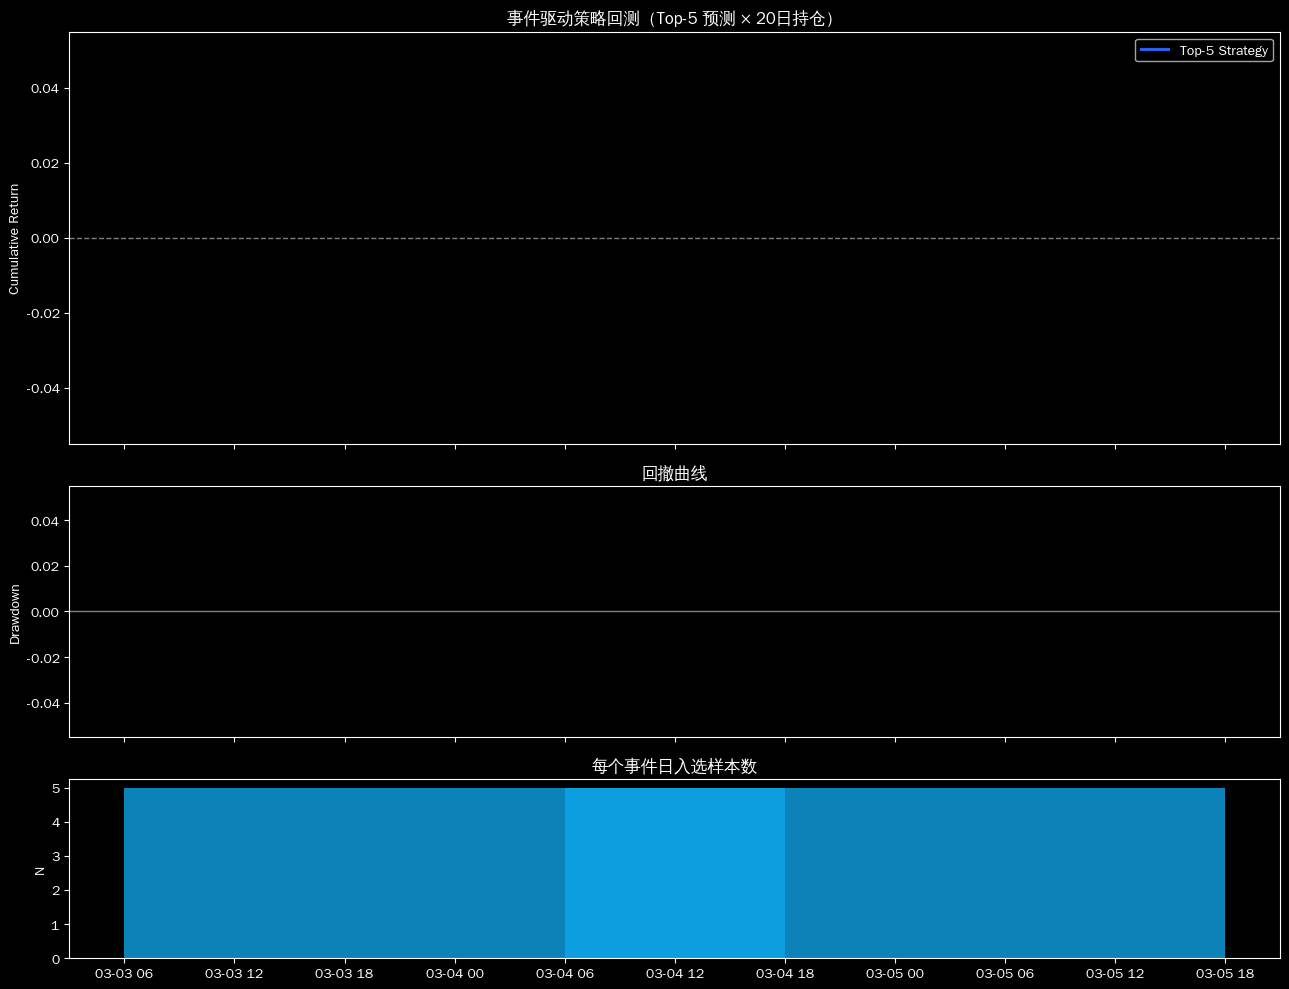

Backtest samples      : 2 event-days
Mean daily return     : +nan
Win rate              : 0.00%
Annualized Sharpe*    : nan
Max drawdown          : nan%
*Sharpe uses 252-day annualization on event-day series.


In [14]:
# Enhanced backtest: select Top-5 predicted return_20d per event-day
# and evaluate cumulative return + drawdown + sample quality.

if not df.empty and 'return_20d' in df.columns and model._models:
    feat_cols = model._feature_cols
    X_all = df[feat_cols].fillna(0).to_numpy(dtype='float32')
    preds_20d = model._models['return_20d'].predict(X_all)

    date_col = 'date' if 'date' in df.columns else ('date_x' if 'date_x' in df.columns else None)
    if date_col is None:
        raise KeyError(f'No date column found. columns={list(df.columns)}')

    df_bt = df[[date_col, 'symbol', 'return_20d']].copy()
    df_bt = df_bt.rename(columns={date_col: 'date'})
    df_bt['pred_return_20d'] = preds_20d
    df_bt['date'] = pd.to_datetime(df_bt['date'])

    grouped = []
    for dt, g in df_bt.groupby('date'):
        top5 = g.nlargest(5, 'pred_return_20d')
        grouped.append({
            'date': dt,
            'mean_actual': top5['return_20d'].mean(),
            'mean_pred': top5['pred_return_20d'].mean(),
            'n_selected': len(top5),
        })

    bt_df = pd.DataFrame(grouped).sort_values('date').set_index('date')
    if bt_df.empty:
        print('No backtest samples after grouping.')
    else:
        bt_df['cum_actual'] = (1 + bt_df['mean_actual']).cumprod() - 1
        bt_df['equity'] = 1 + bt_df['cum_actual']
        bt_df['running_peak'] = bt_df['equity'].cummax()
        bt_df['drawdown'] = bt_df['equity'] / bt_df['running_peak'] - 1

        fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True,
                                 gridspec_kw={'height_ratios': [2.3, 1.4, 1.0]})

        # 1) Equity curve
        axes[0].plot(bt_df.index, bt_df['cum_actual'], color='#2563eb', lw=2.2, label='Top-5 Strategy')
        axes[0].axhline(0, color='gray', lw=1, ls='--')
        axes[0].fill_between(bt_df.index, 0, bt_df['cum_actual'],
                             where=(bt_df['cum_actual'] >= 0), color='#93c5fd', alpha=0.25)
        axes[0].fill_between(bt_df.index, 0, bt_df['cum_actual'],
                             where=(bt_df['cum_actual'] < 0), color='#fca5a5', alpha=0.20)
        axes[0].set_ylabel('Cumulative Return')
        axes[0].set_title('事件驱动策略回测（Top-5 预测 × 20日持仓）')
        axes[0].legend(loc='best')

        # 2) Drawdown
        axes[1].fill_between(bt_df.index, bt_df['drawdown'], 0, color='#dc2626', alpha=0.35)
        axes[1].plot(bt_df.index, bt_df['drawdown'], color='#b91c1c', lw=1.5)
        axes[1].axhline(0, color='gray', lw=1)
        axes[1].set_ylabel('Drawdown')
        axes[1].set_title('回撤曲线')

        # 3) Sample count per day
        axes[2].bar(bt_df.index, bt_df['n_selected'], color='#0ea5e9', alpha=0.8, width=1.5)
        axes[2].set_ylabel('N')
        axes[2].set_title('每个事件日入选样本数')

        plt.tight_layout()
        plt.show()

        mean_r = bt_df['mean_actual'].mean()
        std_r = bt_df['mean_actual'].std(ddof=1)
        sharpe = (mean_r / std_r) * (252 ** 0.5) if std_r and std_r > 0 else float('nan')
        win_rate = (bt_df['mean_actual'] > 0).mean()
        max_dd = bt_df['drawdown'].min()

        print(f'Backtest samples      : {len(bt_df)} event-days')
        print(f'Mean daily return     : {mean_r:+.4f}')
        print(f'Win rate              : {win_rate:.2%}')
        print(f'Annualized Sharpe*    : {sharpe:.3f}')
        print(f'Max drawdown          : {max_dd:.2%}')
        print('*Sharpe uses 252-day annualization on event-day series.')
else:
    print('Need trained model + merged dataframe with return_20d.')


## 8 · 知识图谱传导路径可视化

In [10]:
from trade_py.analysis.knowledge_graph import SectorGraph, SW_NAMES_ZH

sg = SectorGraph()
results = sg.propagate_event('semiconductor_policy', max_hop=2)

print('半导体政策事件传导路径（Top 15）:')
print(f'{"排名":<4} {"板块":<16} {"分数":>8} {"跳数":>6} {"时滞":>8} 传导路径')
print('-' * 80)
for i, r in enumerate(results[:15], 1):
    path_str = ' -> '.join(r.path[-3:])
    print(f'{i:<4} {r.sector_name:<16} {r.score:>+8.3f} {r.hop:>6}d {r.typical_days:>7}d  {path_str}')

半导体政策事件传导路径（Top 15）:
排名   板块                     分数     跳数       时滞 传导路径
--------------------------------------------------------------------------------
1    电子                 +0.900      1d       0d  event:semiconductor_policy -> SW_Electronics
2    计算机                +0.700      1d       0d  event:semiconductor_policy -> SW_Computer
3    有色金属               +0.600      1d       0d  event:semiconductor_policy -> SW_NonFerrousMetal
4    国防军工               +0.550      1d       0d  event:semiconductor_policy -> SW_Defense
5    电气设备               +0.500      1d       0d  event:semiconductor_policy -> SW_ElectricalEquipment
6    通信                 +0.450      2d      12d  event:semiconductor_policy -> SW_Electronics -> SW_Telecom
7    汽车                 +0.405      2d      12d  event:semiconductor_policy -> SW_Electronics -> SW_Auto
8    机械设备               +0.400      1d       0d  event:semiconductor_policy -> SW_MechanicalEquipment
9    采掘                 +0.300      2d       2d  event:s

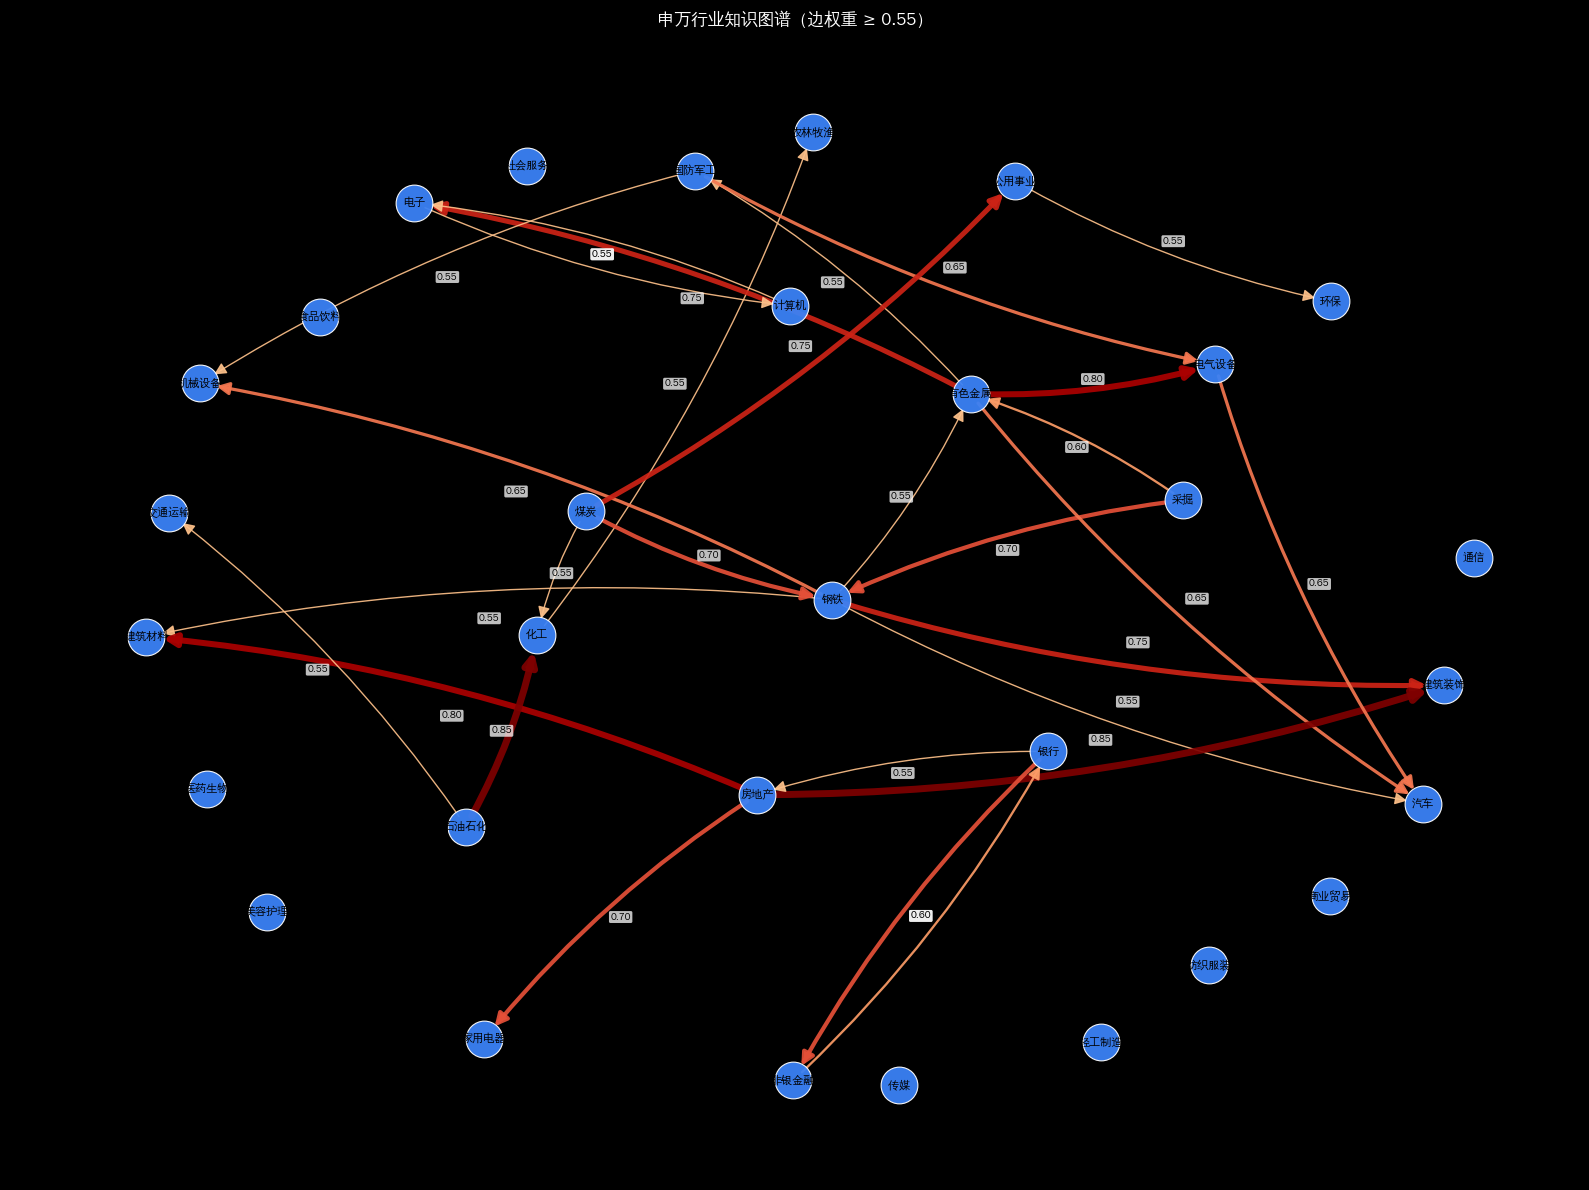

节点数: 31  边数: 29  阈值: 0.55


In [12]:
try:
    import networkx as nx
    from trade_py.analysis.knowledge_graph import SW, SW_NAMES_ZH, _EDGES

    G = nx.DiGraph()
    for sw in SW:
        G.add_node(sw.name, label=SW_NAMES_ZH.get(sw, sw.name))

    edge_threshold = 0.55
    for edge in _EDGES:
        if edge.weight >= edge_threshold:
            G.add_edge(edge.source.name, edge.target.name, weight=float(edge.weight))

    pos = nx.spring_layout(G, k=1.8, seed=42, iterations=120)

    fig, ax = plt.subplots(figsize=(16, 12))
    labels = {n: G.nodes[n]['label'] for n in G.nodes}

    weights = [G[u][v]['weight'] for u, v in G.edges()]
    if weights:
        w_min, w_max = min(weights), max(weights)
        span = max(w_max - w_min, 1e-6)
        edge_widths = [1.0 + 4.0 * (w - w_min) / span for w in weights]
        edge_colors = [plt.cm.OrRd(0.35 + 0.65 * (w - w_min) / span) for w in weights]
    else:
        edge_widths, edge_colors = 1.0, 'gray'

    nx.draw_networkx_nodes(
        G, pos,
        node_size=700,
        node_color='#3b82f6',
        edgecolors='white',
        linewidths=0.8,
        alpha=0.95,
        ax=ax,
    )
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=8, font_color='black', ax=ax)
    nx.draw_networkx_edges(
        G, pos,
        width=edge_widths,
        edge_color=edge_colors,
        alpha=0.92,
        arrows=True,
        arrowsize=18,
        arrowstyle='-|>',
        connectionstyle='arc3,rad=0.08',
        min_source_margin=8,
        min_target_margin=12,
        ax=ax,
    )

    # 仅给高权重边打标签，避免太乱
    top_edges = sorted(G.edges(data=True), key=lambda x: x[2].get('weight', 0), reverse=True)[:30]
    edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in top_edges}
    nx.draw_networkx_edge_labels(
        G, pos,
        edge_labels=edge_labels,
        font_size=7,
        rotate=False,
        bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='none', alpha=0.75),
        ax=ax,
    )

    ax.set_title(f'申万行业知识图谱（边权重 ≥ {edge_threshold:.2f}）')
    ax.axis('off')
    plt.tight_layout()
    plt.show()
    print(f'节点数: {G.number_of_nodes()}  边数: {G.number_of_edges()}  阈值: {edge_threshold:.2f}')
except ImportError:
    print('networkx not installed')
